In [52]:
import pandas as pd


In [ ]:
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_noexhi/master_melted_df.csv.gz")
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_noexhi/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_allcells/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_feb2026_noexhi/master_melted_df.csv.gz", index_col=0)
# df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/real_go_apr2026_noexi/master_melted_df.csv.gz", index_col=0)
# df= pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_noexi_noexirealy/master_melted_df.csv.gz", index_col=0)

# good one
df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels/master_melted_df.csv.gz", index_col=0) 
# Replication
df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/archive/bulkSimulationOneProfile/results/fakebulk_reallabels_attempt2/master_melted_df.csv.gz", index_col=0)
df['exp'] = df['organism_part'].str.split("_").str[0]
df = df[df.exp=="exp"]
df.sort_values("auc")

,index,organism_part,bootstrap,variance,auc,exp
453,GO:0010667,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,31,0.05,0.205783,exp
1373,GO:2000147,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,26,0.05,0.242677,exp
22,GO:0000423,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,15,0.05,0.243561,exp
22,GO:0000423,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,20,0.05,0.250507,exp
22,GO:0000423,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,26,0.05,0.251158,exp
...,...,...,...,...,...,...
1089,GO:0050911,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,40,0.05,0.844728,exp
1089,GO:0050911,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,39,0.05,0.847843,exp
1089,GO:0050911,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,9,0.05,0.853155,exp
1089,GO:0050911,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,21,0.05,0.863334,exp


<Axes: xlabel='exp', ylabel='auc'>

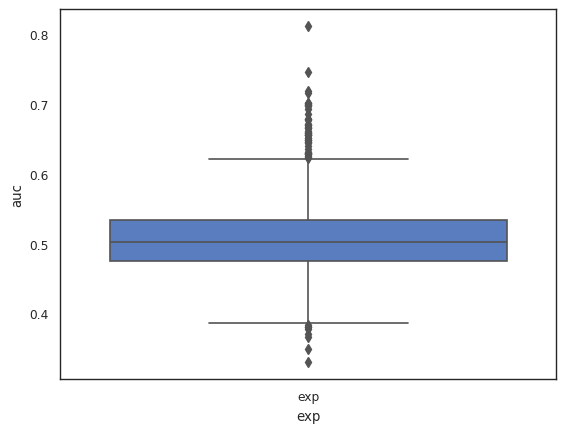

In [54]:
import seaborn as sns
p= df.groupby(['index','exp'])['auc'].mean().reset_index()
sns.boxplot(data = p, x = "exp", y = "auc")

In [55]:
import anndata as ad
import scanpy as sc
import numpy as np

In [56]:
adata = ad.read_h5ad("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessSC_pipe/data/h5ad_datasets/processed/cpm/brain_sc_with_metadata_pc_cpm.h5ad")
adata.obs

,cluster,umap_x,umap_y,Tissue,Cluster,Cell type,Cell type group,Cell count,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,norm_factor
0,15,-1.78285,10.86050,Brain,c-15,Inhibitory neurons,Neuronal cells,1993,4379,4379,13035,117,0.897583,13035.0
1,29,4.73990,2.35851,Brain,c-29,Excitatory neurons,Neuronal cells,925,3933,3933,10441,29,0.277751,10441.0
2,10,14.46040,-0.62549,Brain,c-10,Excitatory neurons,Neuronal cells,2401,4656,4656,13994,79,0.564528,13994.0
3,24,6.90615,6.53858,Brain,c-24,Excitatory neurons,Neuronal cells,1293,1507,1507,2612,95,3.637060,2612.0
4,12,5.23585,18.32610,Brain,c-12,Oligodendrocytes,Glial cells,2309,2267,2267,4666,6,0.128590,4666.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76528,12,2.69780,18.02410,Brain,c-12,Oligodendrocytes,Glial cells,2309,1372,1372,2364,2,0.084602,2364.0
76529,2,10.02080,-2.03955,Brain,c-2,Excitatory neurons,Neuronal cells,3732,6039,6039,28839,117,0.405701,28839.0
76530,9,13.34780,5.03476,Brain,c-9,Excitatory neurons,Neuronal cells,2451,1189,1189,1867,4,0.214247,1867.0
76531,12,3.04571,16.96410,Brain,c-12,Oligodendrocytes,Glial cells,2309,1561,1561,2943,32,1.087326,2943.0


In [57]:
exci = adata[adata.obs.loc[:,'Cell type']== "Excitatory neurons"]
exci_mean = exci.X.mean(axis = 0)
exci = pd.DataFrame(exci_mean, index = exci.var.index, columns = ['exci'])

In [58]:
non = adata[adata.obs.loc[:,'Cell type']!= "Excitatory neurons"]
non_mean = non.X.mean(axis = 0)
non = pd.DataFrame(non_mean, index = non.var.index, columns = ['non'])

In [59]:
both = exci.merge(non, left_index=True, right_index=True)
both['fc'] = both['exci']/both['non']
both['log2fc'] = np.log2(both['fc'])
both.sort_values('log2fc')
t=both[both.log2fc > 1]

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [60]:
t

,exci,non,fc,log2fc
ensembl_gene_id,,,,
ENSG00000002746,720.579712,188.021744,3.832428,1.938259
ENSG00000003137,6.923940,0.909390,7.613828,2.928622
ENSG00000004399,14.694117,5.480503,2.681162,1.422858
ENSG00000004660,73.252739,17.873678,4.098358,2.035046
ENSG00000005001,0.016030,0.006083,2.634961,1.397782
...,...,...,...,...
ENSG00000283361,1.913884,0.343418,5.573046,2.478466
ENSG00000284609,0.057187,0.000000,inf,inf
ENSG00000284680,0.004828,0.000000,inf,inf


In [ ]:
import scanpy as sc
# Basic normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Save normalized data in adata.raw (recommended)
adata.raw = adata

# Define the group of interest
group = "Excitatory neurons"

# Create a binary label: ONE vs ALL
adata.obs["one_vs_all"] = (
    adata.obs["Cell type"].eq(group)
).astype(str)

# keep genes expressed in at least 5 cells OR in at least 5% of the target group
from scipy import sparse
import numpy as np

# compute fraction expressed in the True group
def frac_expr(adata_sub):
    X = adata_sub.X
    if sparse.issparse(X):
        return (X.astype(bool).sum(axis=0).A1 / X.shape[0])
    else:
        return (np.count_nonzero(X, axis=0) / X.shape[0])

frac_true = frac_expr(adata[adata.obs["one_vs_all"] == "True"])

# thresholds
min_cells = 100
min_frac_in_group = 0.1

# keep genes expressed in >= min_cells in entire dataset
if sparse.issparse(adata.X):
    keep = (adata.X.astype(bool).sum(axis=0).A1 >= min_cells)
else:
    keep = (np.count_nonzero(adata.X, axis=0) >= min_cells)

# also keep genes expressed in >= 5% of the target group
keep = keep | (frac_true >= min_frac_in_group)

print("Kept genes:", keep.sum(), "of", adata.shape[1])

# filter
adata = adata[:, keep].copy()
# sc.pp.filter_genes(adata, min_cells=5)

# Run differential expression (wilcoxon)
sc.tl.rank_genes_groups(
    adata,
    groupby="one_vs_all",
    method="wilcoxon",
    reference="rest"       # one vs all
)

# Extract results into a table
deg = sc.get.rank_genes_groups_df(adata, group="True")
deg.head()


Kept genes: 16334 of 17724


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


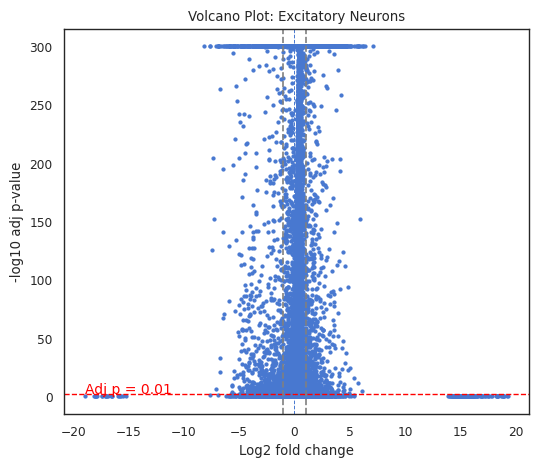

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

deg = sc.get.rank_genes_groups_df(adata, group="True")

x = deg["logfoldchanges"]
y = -np.log10(deg["pvals_adj"] + 1e-300)

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=5)

# significance line @ adj p-value = 0.05
p_thresh = 0.01
yline = -np.log10(p_thresh)

plt.axhline(yline, color="red", linestyle="--", linewidth=1)
plt.text(
    x.min(), 
    yline + 0.1, 
    f"Adj p = {p_thresh}", 
    color="red", 
    fontsize=10
)
plt.axvline(1, color="gray", linestyle="--")
plt.axvline(-1, color="gray", linestyle="--")

plt.xlabel("Log2 fold change")
plt.ylabel("-log10 adj p-value")
plt.title("Volcano Plot: Excitatory Neurons")

plt.axvline(0, linestyle="--", linewidth=0.7)
plt.show()


In [ ]:
# dea = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/deconvolutingBulk/bin/notebooks/all_gene_marker_scores.csv", index_col=0)
# dea = dea[dea.loc[:,'group'] == "Excitatory neurons" ]
# dea = dea[dea.pvals_adj <=0.01]
# dea = dea[dea.logfoldchanges < -1]
# dea.sort_values("pvals_adj")

In [ ]:
# dea = dea[dea.pvals_adj <=0.01]
# dea = dea[dea.logfoldchanges < -1]

In [ ]:
dea =  deg[deg.pvals_adj <=0.05]
dea = dea[dea.logfoldchanges > 1]
dea

,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000185518,226.082550,5.747296,0.000000,0.000000
1,ENSG00000119042,224.349411,6.378094,0.000000,0.000000
2,ENSG00000081803,216.986740,5.981803,0.000000,0.000000
3,ENSG00000112137,216.873322,2.329651,0.000000,0.000000
4,ENSG00000128656,215.610840,2.843074,0.000000,0.000000
...,...,...,...,...,...
10997,ENSG00000132681,2.120195,1.474342,0.033990,0.045987
11001,ENSG00000170426,2.117442,1.011903,0.034222,0.046288
11006,ENSG00000130957,2.108174,1.060590,0.035016,0.047332
11007,ENSG00000124232,2.102526,1.121297,0.035507,0.047993


In [ ]:
# Load GO term annotations
go_annot_path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/processing/bp_annotations_withGeneData_qc_annotations.csv"
go_annot = pd.read_csv(go_annot_path)
go_annot = go_annot.loc[:,["GO ID", "DB_Object_Symbol", "ensembl_gene_id"]]
go_annot

,GO ID,DB_Object_Symbol,ensembl_gene_id
0,GO:0000045,IRGM,ENSG00000237693
1,GO:0000045,BECN2,ENSG00000196289
2,GO:0000045,AP4M1,ENSG00000221838
3,GO:0000045,ATG13,ENSG00000175224
4,GO:0000045,ULK1,ENSG00000177169
...,...,...,...
76885,GO:2001244,BOK,ENSG00000176720
76886,GO:2001244,PLAGL2,ENSG00000126003
76887,GO:2001244,FIS1,ENSG00000214253
76888,GO:2001244,RIPK3,ENSG00000285379


In [ ]:
# get size of each GO
go_sizes = go_annot.groupby("GO ID").size().reset_index(name = 'size')
go_sizes

,GO ID,size
0,GO:0000045,63
1,GO:0000070,33
2,GO:0000077,35
3,GO:0000079,52
4,GO:0000082,64
...,...,...
1397,GO:2001237,37
1398,GO:2001238,27
1399,GO:2001240,34
1400,GO:2001243,23


In [ ]:
# get number of exi genes in each GO
n_in  = pd.merge(go_annot, dea, left_on = "ensembl_gene_id", right_on='names').groupby("GO ID").size().reset_index(name = 'size_in')
n_in.sort_values('size_in')

,GO ID,size_in
1261,GO:2001243,1
831,GO:0045662,1
202,GO:0006956,1
821,GO:0045454,1
817,GO:0045333,1
...,...,...
275,GO:0007283,44
284,GO:0007399,47
686,GO:0035556,49
135,GO:0006468,56


In [ ]:
percent = pd.merge(go_sizes, n_in, on = "GO ID")
percent['percent'] = percent['size_in']/percent['size']
percent.sort_values(by = 'percent')

,GO ID,size,size_in,percent
614,GO:0032543,95,1,0.010526
15,GO:0000398,181,2,0.011050
440,GO:0016236,69,1,0.014493
132,GO:0006417,68,1,0.014706
349,GO:0009060,66,1,0.015152
...,...,...,...,...
985,GO:0050919,39,12,0.307692
657,GO:0034332,32,10,0.312500
661,GO:0034587,22,7,0.318182
1191,GO:0099170,22,7,0.318182


In [ ]:
df_plot = pd.DataFrame(df.groupby(['index', 'exp'])['auc'].median()).reset_index()
df_plot.columns = ["GO ID", 'exp', "auc"]
df_plot = df_plot.merge(percent, on = "GO ID", how = 'left')
df_plot = df_plot[df_plot.size_in>=df_plot["size_in"].quantile(0.9)]
df_plot['percent'] = df_plot['percent'].fillna(0)
df_plot.sort_values('auc')
df_plot.sort_values("auc", ascending=False)
df_plot = df_plot[df_plot.loc[:,'GO ID']!= "GO:0050911"]

In [ ]:
df

,index,organism_part,bootstrap,variance,auc,exp
0,GO:0000045,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,6,0.05,0.504602,exp
1,GO:0000070,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,6,0.05,0.487232,exp
2,GO:0000077,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,6,0.05,0.573943,exp
3,GO:0000079,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,6,0.05,0.465997,exp
4,GO:0000082,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,6,0.05,0.490085,exp
...,...,...,...,...,...,...
1392,GO:2001237,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,5,0.05,0.458801,exp
1393,GO:2001238,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,5,0.05,0.409609,exp
1394,GO:2001240,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,5,0.05,0.505738,exp
1395,GO:2001243,exp_brain_sc_with_metadata_pc_cpm_cell_type_pr...,5,0.05,0.501142,exp


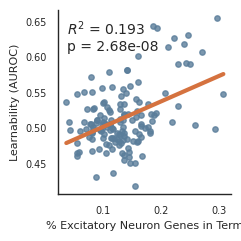

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Compute linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_plot['percent'], df_plot['auc'])
r_squared = r_value**2

# Set Seaborn style and context for publication
sns.set_theme(style="white", palette="muted")
sns.set_context("paper")

# Create figure
fig, ax = plt.subplots(figsize=(2.5,2.5))

# Scatter plot with regression line
sns.regplot(
    data=df_plot,
    x='percent',
    y='auc',
    ci=None,            # remove confidence interval
    scatter_kws={'s':15, 'color':'#5A7D9A', 'alpha':0.8},  # marker size and color
    line_kws={'color':'#D5723F', 'lw':3},                 # regression line color and thickness
    ax=ax
)

# Add R^2 and p-value
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}\np = {p_value:.3g}",
    transform=ax.transAxes,
    verticalalignment='top',
    fontsize=10
)

# Label axes
ax.set_xlabel('% Excitatory Neuron Genes in Term', fontsize=8)
ax.set_ylabel('Learnability (AUROC)', fontsize=8)
# Make tick labels smaller
ax.tick_params(axis='x', labelsize=7)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=7)  # y-axis tick labels
# ax.set_title('Regression of AUC vs Percent', fontsize=12)

# Tidy up spines
sns.despine(ax=ax)

# Save publication-ready figure
plt.tight_layout()
plt.savefig("results/auc_vs_percent.pdf", transparent=True)
plt.savefig("results/auc_vs_percent.png", dpi=300, transparent=True)
plt.show()